<a href="https://colab.research.google.com/github/SHUBHI289/Celebal-Technologies-training/blob/main/Week6_shubhi_gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

In [7]:
# Load Dataset
(train_images, _), (test_images, _) = mnist.load_data()

train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)


In [8]:
def create_noisy_images(images, noise_level=0.4):
    noise = np.random.randn(*images.shape) * noise_level
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0)

train_noisy = create_noisy_images(train_images)
test_noisy = create_noisy_images(test_images)


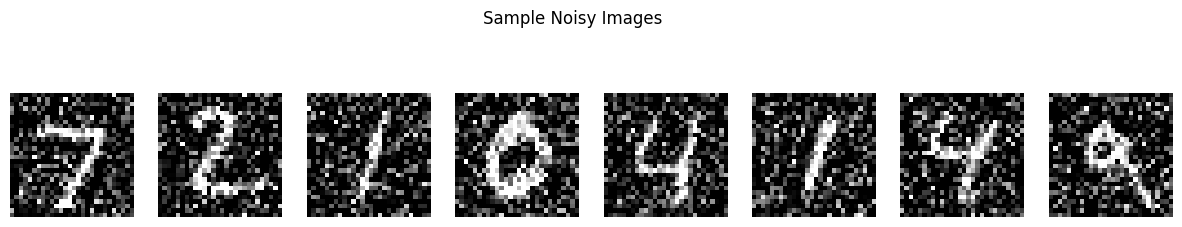

In [9]:

# Display Sample Noisy Images

plt.figure(figsize=(15,3))

for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Sample Noisy Images")
plt.show()


In [10]:
# Build Autoencoder

inputs = Input(shape=(28,28,1))

# Encoder
x = Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = MaxPooling2D(2, padding='same')(x)

x = Conv2D(8, 3, activation='relu', padding='same')(x)
encoded = MaxPooling2D(2, padding='same')(x)

# Decoder
x = Conv2D(8, 3, activation='relu', padding='same')(encoded)
x = UpSampling2D(2)(x)

x = Conv2D(16, 3, activation='relu', padding='same')(x)
x = UpSampling2D(2)(x)

outputs = Conv2D(1, 3, activation='sigmoid', padding='same')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:

# Train Model

history = model.fit(
    train_noisy,
    train_images,
    epochs=12,
    batch_size=64,
    validation_data=(test_noisy, test_images),
    verbose=1
)

Epoch 1/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 96s 100ms/step - loss: 0.1139 - val_loss: 0.1140
Epoch 2/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 86ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 92ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 148s 99ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 92ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 86ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 11/12
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 83ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 12/12
938/938 ━━━━━━━

In [12]:
# Predict
clean_predictions = model.predict(test_noisy)



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


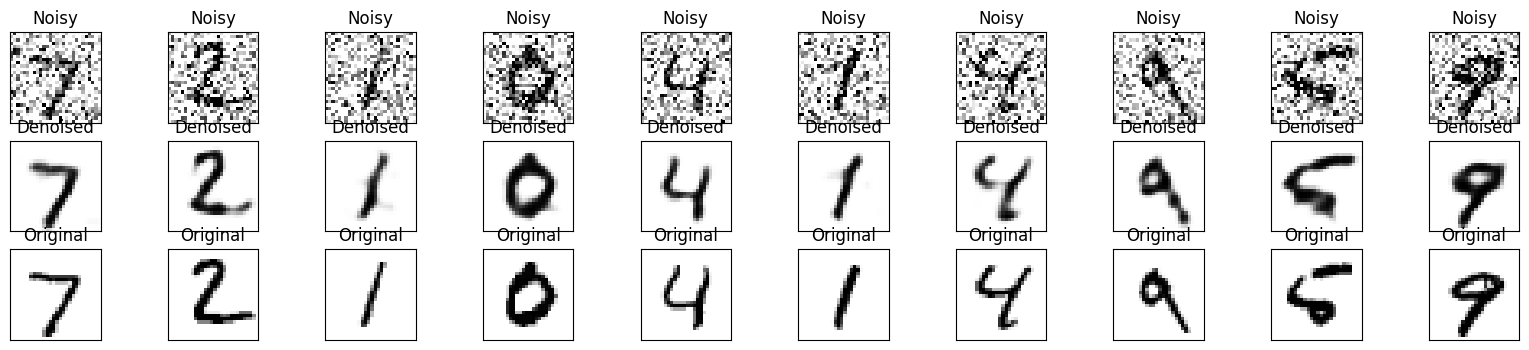

In [15]:
# Generate denoised outputs on the test set
denoised_images = autoencoder.predict(x_test_noisy)

# Result Visualization: Original, noisy and reconstructed images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # original (Noisy)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='binary')
    plt.title("Noisy")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed (Denoised)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='binary')
    plt.title("Denoised")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Clean (Original Ground Truth)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='binary')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()